Synthesizing 256x256 High-Res object from 49 Low-Res 64x64 captures.
Running reconstruction for 10 iterations...


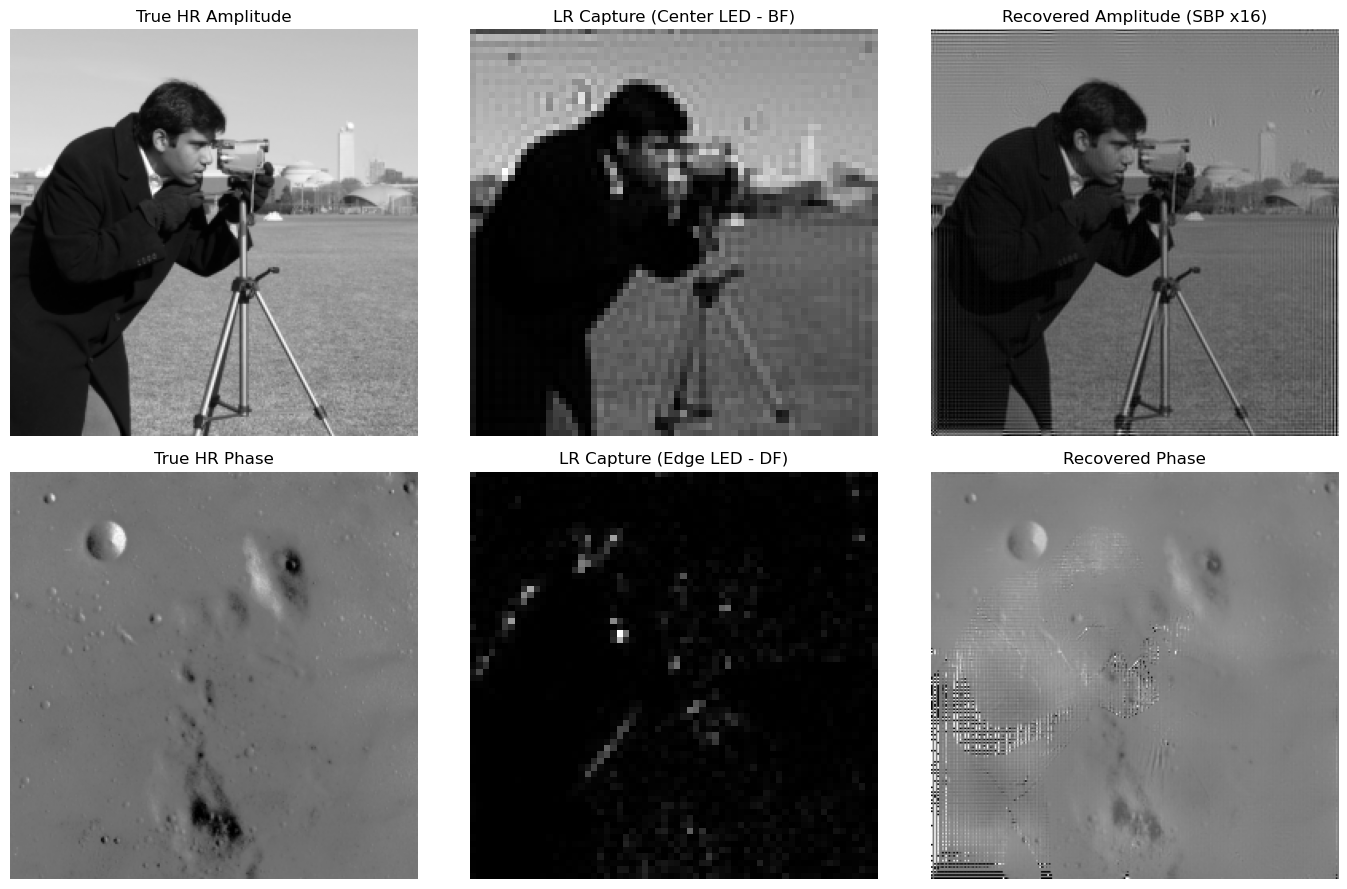

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, transform

def run_fpm_simulation():
    # ==========================================
    # 1. SYSTEM PARAMETERS & OPTICAL SETUP
    # ==========================================
    # Illumination & Setup
    wavelength = 0.532e-6      # Green LED wavelength (m)
    n_leds_1d = 7              # 7x7 LED array
    led_pitch = 4e-3           # 4mm spacing between LEDs
    z_led = 60e-3              # 60mm distance from LED to sample
    
    # Objective Lens & Camera
    NA = 0.08                   # Objective Numerical Aperture
    mag = 2.0                  # Magnification
    dpix_c = 6.5e-6            # Typical sCMOS camera pixel size (m)
    dpix_o = dpix_c / mag      # Effective pixel size at the object plane (3.25 um)
    
    # Grid Sizes (Powers of 2 for efficient FFT)
    N_LR = 64                  # Low-Res image dimensions (64x64)
    ds = 4                     # Upsampling factor for High-Res reconstruction
    N_HR = N_LR * ds           # High-Res object dimensions (256x256)
    dpix_HR = dpix_o / ds      # High-Res pixel size (0.8125 um)

    print(f"Synthesizing {N_HR}x{N_HR} High-Res object from {n_leds_1d**2} Low-Res {N_LR}x{N_LR} captures.")

    # ==========================================
    # 2. GENERATE GROUND TRUTH OBJECT
    # ==========================================
    # Amplitude: Cameraman, Phase: Moon
    amp = transform.resize(data.camera(), (N_HR, N_HR), anti_aliasing=True)
    amp = amp / amp.max() 
    
    phase = transform.resize(data.moon(), (N_HR, N_HR), anti_aliasing=True)
    phase = (phase / phase.max()) * np.pi - (np.pi/2) # Scale phase between -pi/2 and pi/2
    
    obj_true = amp * np.exp(1j * phase)
    
    # High-Res frequency space coordinates
    df_HR = 1.0 / (N_HR * dpix_HR)
    
    # ==========================================
    # 3. CONSTRUCT THE PUPIL FUNCTION (CTF)
    # ==========================================
    # The pupil acts as a low-pass filter in the Fourier domain
    fx_LR = np.fft.fftshift(np.fft.fftfreq(N_LR, d=dpix_o))
    fy_LR = np.fft.fftshift(np.fft.fftfreq(N_LR, d=dpix_o))
    FX_LR, FY_LR = np.meshgrid(fx_LR, fy_LR)
    
    cutoff_freq = NA / wavelength
    pupil = (FX_LR**2 + FY_LR**2 <= cutoff_freq**2).astype(float)
    
    # ==========================================
    # 4. FORWARD MODEL (SIMULATING LR CAPTURES)
    # ==========================================
    # Calculate LED positions and corresponding frequency shifts
    led_idx = np.arange(-(n_leds_1d//2), n_leds_1d//2 + 1)
    x_led, y_led = np.meshgrid(led_idx * led_pitch, led_idx * led_pitch)
    
    # Illumination angles and k-vector shifts
    sin_theta_x = x_led / np.sqrt(x_led**2 + y_led**2 + z_led**2)
    sin_theta_y = y_led / np.sqrt(x_led**2 + y_led**2 + z_led**2)
    
    kx_led = -sin_theta_x / wavelength
    ky_led = -sin_theta_y / wavelength
    
    # Generate HR Object Spectrum
    O_HR = np.fft.fftshift(np.fft.fft2(obj_true))
    
    # Store captured Low-Res intensity images
    I_measure = np.zeros((n_leds_1d, n_leds_1d, N_LR, N_LR))
    
    for i in range(n_leds_1d):
        for j in range(n_leds_1d):
            # Calculate shift in matrix indices
            c_x = int(N_HR/2 + kx_led[i,j] / df_HR)
            c_y = int(N_HR/2 + ky_led[i,j] / df_HR)
            
            # Extract shifted spectrum patch
            patch = O_HR[c_y - N_LR//2 : c_y + N_LR//2, c_x - N_LR//2 : c_x + N_LR//2]
            
            # Apply objective pupil
            patch_filtered = patch * pupil
            
            # Inverse FFT to sensor plane
            lr_field = np.fft.ifft2(np.fft.ifftshift(patch_filtered))
            
            # Camera captures intensity (absolute square)
            I_measure[i,j] = np.abs(lr_field)**2

    # ==========================================
    # 5. INVERSE MODEL (FPM RECONSTRUCTION)
    # ==========================================
    # Gerchberg-Saxton / Alternating Projections algorithm
    iterations = 10
    alpha = 1.0 # Step size / relaxation parameter
    
    # Initialize guess (upsampled central image)
    center_idx = n_leds_1d // 2
    init_amp = transform.resize(np.sqrt(I_measure[center_idx, center_idx]), (N_HR, N_HR))
    O_rec = np.fft.fftshift(np.fft.fft2(init_amp)) 
    
    print(f"Running reconstruction for {iterations} iterations...")
    
    for it in range(iterations):
        # Optional: Randomize or spiral LED update order for better convergence
        for i in range(n_leds_1d):
            for j in range(n_leds_1d):
                c_x = int(N_HR/2 + kx_led[i,j] / df_HR)
                c_y = int(N_HR/2 + ky_led[i,j] / df_HR)
                
                # 1. Extract current guess spectrum patch
                patch_rec = O_rec[c_y - N_LR//2 : c_y + N_LR//2, c_x - N_LR//2 : c_x + N_LR//2]
                
                # 2. Apply pupil
                patch_filtered_rec = patch_rec * pupil
                
                # 3. Transform to spatial domain
                lr_field_rec = np.fft.ifft2(np.fft.ifftshift(patch_filtered_rec))
                
                # 4. Amplitude Constraint: Replace calculated amplitude with measured amplitude
                lr_field_updated = np.sqrt(I_measure[i,j]) * np.exp(1j * np.angle(lr_field_rec))
                
                # 5. Transform back to frequency domain
                patch_updated = np.fft.fftshift(np.fft.fft2(lr_field_updated)) * pupil
                
                # 6. Update High-Res spectrum (with support mask)
                O_rec[c_y - N_LR//2 : c_y + N_LR//2, c_x - N_LR//2 : c_x + N_LR//2] += \
                    alpha * np.abs(pupil) * (patch_updated - patch_filtered_rec)

    # Recover final spatial HR object
    obj_rec = np.fft.ifft2(np.fft.ifftshift(O_rec))

    # ==========================================
    # 6. VISUALIZATION
    # ==========================================
    fig, axs = plt.subplots(2, 3, figsize=(14, 9))
    
    axs[0,0].imshow(np.abs(obj_true), cmap='gray')
    axs[0,0].set_title('True HR Amplitude')
    axs[0,0].axis('off')
    
    axs[1,0].imshow(np.angle(obj_true), cmap='gray')
    axs[1,0].set_title('True HR Phase')
    axs[1,0].axis('off')
    
    # Show center LED (Brightfield) vs Edge LED (Darkfield)
    axs[0,1].imshow(I_measure[center_idx, center_idx], cmap='gray')
    axs[0,1].set_title('LR Capture (Center LED - BF)')
    axs[0,1].axis('off')
    
    axs[1,1].imshow(I_measure[0, 0], cmap='gray')
    axs[1,1].set_title('LR Capture (Edge LED - DF)')
    axs[1,1].axis('off')
    
    axs[0,2].imshow(np.abs(obj_rec), cmap='gray')
    axs[0,2].set_title(f'Recovered Amplitude (SBP x{ds**2})')
    axs[0,2].axis('off')
    
    axs[1,2].imshow(np.angle(obj_rec), cmap='gray')
    axs[1,2].set_title('Recovered Phase')
    axs[1,2].axis('off')
    
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    run_fpm_simulation()

Generating complex object...
Simulating Forward Model (Acquiring LR images)...
Starting Reconstruction...
Iteration 10/30 complete.
Iteration 20/30 complete.
Iteration 30/30 complete.


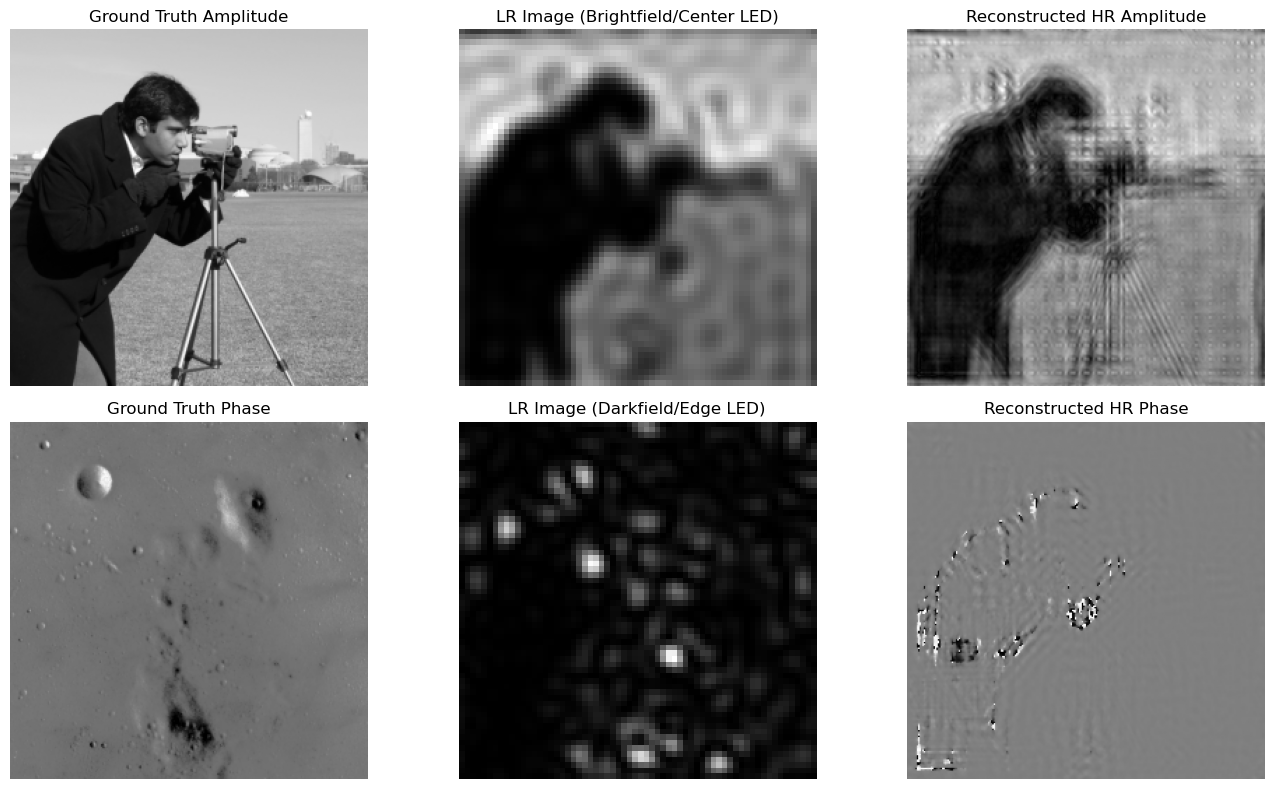

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data
from skimage.transform import resize

# ==========================================
# 1. System Parameters & Optical Setup
# ==========================================
# Wavelength and hardware specs
wvl = 0.532e-3  # Wavelength in mm (532 nm)
NA = 0.1        # Numerical Aperture of objective
mag = 2.0       # Magnification

# LED Array specs
led_num = 7             # 7x7 LED array
led_pitch = 4.0         # spacing between LEDs in mm
z_led = 60.0            # distance from LED array to sample in mm

# Camera specs
cam_pixel = 6.5e-3      # Camera sensor pixel size in mm
dx_lr = cam_pixel / mag # Effective pixel size at object plane (Low Res)

# Computational Grid specs
# We want to reconstruct a High-Resolution (HR) image from Low-Resolution (LR) images
upsample_factor = 4     
dx_hr = dx_lr / upsample_factor # Effective pixel size in HR space
LR_size = 64            # Size of captured LR images (64x64 pixels)
HR_size = LR_size * upsample_factor # Size of HR object (256x256 pixels)

# ==========================================
# 2. Generate Synthetic Complex Object
# ==========================================
print("Generating complex object...")
# Load standard images for Amplitude (Cameraman) and Phase (Moon)
amp = data.camera().astype(float)
amp = resize(amp, (HR_size, HR_size), anti_aliasing=True)
amp = amp / np.max(amp) # Normalize to [0, 1]

phase = data.moon().astype(float)
phase = resize(phase, (HR_size, HR_size), anti_aliasing=True)
phase = (phase / np.max(phase)) * np.pi - (np.pi/2) # Scale phase to [-pi/2, pi/2]

# The Ground Truth Complex Object
O_gt = amp * np.exp(1j * phase)
O_gt_fourier = np.fft.fftshift(np.fft.fft2(O_gt))

# ==========================================
# 3. Define Fourier Space and Pupil Function
# ==========================================
# Frequency coordinates for HR space
fx = np.fft.fftshift(np.fft.fftfreq(HR_size, d=dx_hr))
fy = np.fft.fftshift(np.fft.fftfreq(HR_size, d=dx_hr))
FX, FY = np.meshgrid(fx, fy)

# Cutoff frequency of the objective
f_cutoff = NA / wvl

# Coherent Pupil Function (Low-pass filter)
Pupil = np.zeros((HR_size, HR_size))
Pupil[np.sqrt(FX**2 + FY**2) <= f_cutoff] = 1.0

# ==========================================
# 4. Forward Model: Generate LR Images
# ==========================================
print("Simulating Forward Model (Acquiring LR images)...")
lr_images = np.zeros((led_num, led_num, LR_size, LR_size))
k_shifts_x = np.zeros((led_num, led_num))
k_shifts_y = np.zeros((led_num, led_num))

center_led = led_num // 2

for i in range(led_num):
    for j in range(led_num):
        # Physical coordinates of the current LED
        x_pos = (j - center_led) * led_pitch
        y_pos = (i - center_led) * led_pitch
        
        # Illumination angles
        theta_x = np.arctan(x_pos / z_led)
        theta_y = np.arctan(y_pos / z_led)
        
        # Spatial frequency shifts induced by tilted illumination
        kx = np.sin(theta_x) / wvl
        ky = np.sin(theta_y) / wvl
        
        # Save shifts for reconstruction
        k_shifts_x[i, j] = kx
        k_shifts_y[i, j] = ky
        
        # Shift the object spectrum
        # In numerical arrays, we shift the pupil instead to extract the sub-region
        # Find pixel indices for the shifted pupil center
        idx_x = int(np.argmin(np.abs(fx - kx)))
        idx_y = int(np.argmin(np.abs(fy - ky)))
        
        # Crop the region corresponding to the shifted pupil (LR bandwidth)
        # Using a simple square crop bounded by LR_size for computational speed
        half_LR = LR_size // 2
        sub_spectrum = np.zeros((LR_size, LR_size), dtype=complex)
        
        # Handle boundaries carefully
        y_start, y_end = max(0, idx_y - half_LR), min(HR_size, idx_y + half_LR)
        x_start, x_end = max(0, idx_x - half_LR), min(HR_size, idx_x + half_LR)
        
        sub_y_start = half_LR - (idx_y - y_start)
        sub_y_end = half_LR + (y_end - idx_y)
        sub_x_start = half_LR - (idx_x - x_start)
        sub_x_end = half_LR + (x_end - idx_x)
        
        # Extract and apply a smaller version of the pupil
        sub_pupil = np.zeros((LR_size, LR_size))
        fx_sub = np.fft.fftshift(np.fft.fftfreq(LR_size, d=dx_hr))
        fy_sub = np.fft.fftshift(np.fft.fftfreq(LR_size, d=dx_hr))
        FX_sub, FY_sub = np.meshgrid(fx_sub, fy_sub)
        sub_pupil[np.sqrt(FX_sub**2 + FY_sub**2) <= f_cutoff] = 1.0

        sub_spectrum[sub_y_start:sub_y_end, sub_x_start:sub_x_end] = \
            O_gt_fourier[y_start:y_end, x_start:x_end]
            
        # Apply low-pass filter (Pupil)
        filtered_spectrum = sub_spectrum * sub_pupil
        
        # Inverse FFT to get target intensity
        target_field = np.fft.ifft2(np.fft.ifftshift(filtered_spectrum))
        lr_images[i, j, :, :] = np.abs(target_field)**2

# ==========================================
# 5. Reconstruction: Alternating Projections
# ==========================================
print("Starting Reconstruction...")
iterations = 30
# Initialize HR spectrum guess (upsampled central image)
O_rec_fourier = np.zeros((HR_size, HR_size), dtype=complex)
center_img = np.sqrt(lr_images[center_led, center_led, :, :])
O_rec_fourier[HR_size//2-half_LR:HR_size//2+half_LR, HR_size//2-half_LR:HR_size//2+half_LR] = \
    np.fft.fftshift(np.fft.fft2(center_img))

for it in range(iterations):
    for i in range(led_num):
        for j in range(led_num):
            # Calculate indices based on known shifts
            idx_x = int(np.argmin(np.abs(fx - k_shifts_x[i, j])))
            idx_y = int(np.argmin(np.abs(fy - k_shifts_y[i, j])))
            
            y_start, y_end = max(0, idx_y - half_LR), min(HR_size, idx_y + half_LR)
            x_start, x_end = max(0, idx_x - half_LR), min(HR_size, idx_x + half_LR)
            
            sub_y_start = half_LR - (idx_y - y_start)
            sub_y_end = half_LR + (y_end - idx_y)
            sub_x_start = half_LR - (idx_x - x_start)
            sub_x_end = half_LR + (x_end - idx_x)
            
            # 1. Crop from current HR guess
            sub_spectrum = np.zeros((LR_size, LR_size), dtype=complex)
            sub_spectrum[sub_y_start:sub_y_end, sub_x_start:sub_x_end] = \
                O_rec_fourier[y_start:y_end, x_start:x_end]
            
            # Apply pupil
            field_fourier = sub_spectrum * sub_pupil
            
            # 2. Transform to spatial domain
            field_spatial = np.fft.ifft2(np.fft.ifftshift(field_fourier))
            
            # 3. Intensity constraint: Replace amplitude with captured data
            measured_amp = np.sqrt(lr_images[i, j, :, :])
            field_spatial_updated = measured_amp * np.exp(1j * np.angle(field_spatial))
            
            # 4. Transform back to frequency domain
            field_fourier_updated = np.fft.fftshift(np.fft.fft2(field_spatial_updated))
            
            # 5. Update the HR spectrum
            update_region = field_fourier_updated * sub_pupil # Only update within the pupil
            
            # Standard GS update step
            O_rec_fourier[y_start:y_end, x_start:x_end] = \
                np.where(sub_pupil[sub_y_start:sub_y_end, sub_x_start:sub_x_end] == 1,
                         update_region[sub_y_start:sub_y_end, sub_x_start:sub_x_end],
                         O_rec_fourier[y_start:y_end, x_start:x_end])

    if (it + 1) % 10 == 0:
        print(f"Iteration {it + 1}/{iterations} complete.")

# Final spatial domain reconstructed image
O_rec = np.fft.ifft2(np.fft.ifftshift(O_rec_fourier))

# ==========================================
# 6. Visualization
# ==========================================
fig, axes = plt.subplots(2, 3, figsize=(14, 8))

# Ground Truth
axes[0, 0].imshow(np.abs(O_gt), cmap='gray')
axes[0, 0].set_title('Ground Truth Amplitude')
axes[0, 0].axis('off')

axes[1, 0].imshow(np.angle(O_gt), cmap='gray')
axes[1, 0].set_title('Ground Truth Phase')
axes[1, 0].axis('off')

# Low Resolution Input Example
axes[0, 1].imshow(lr_images[center_led, center_led, :, :], cmap='gray')
axes[0, 1].set_title('LR Image (Brightfield/Center LED)')
axes[0, 1].axis('off')

axes[1, 1].imshow(lr_images[0, 0, :, :], cmap='gray')
axes[1, 1].set_title('LR Image (Darkfield/Edge LED)')
axes[1, 1].axis('off')

# Reconstruction
axes[0, 2].imshow(np.abs(O_rec), cmap='gray')
axes[0, 2].set_title('Reconstructed HR Amplitude')
axes[0, 2].axis('off')

axes[1, 2].imshow(np.angle(O_rec), cmap='gray')
axes[1, 2].set_title('Reconstructed HR Phase')
axes[1, 2].axis('off')

plt.tight_layout()
plt.show()

Preparing Ground Truth Object...
Simulating LED Illuminations and capturing LR images...
Starting FPM Reconstruction...
Iteration 5/30
Iteration 10/30
Iteration 15/30
Iteration 20/30
Iteration 25/30
Iteration 30/30
Plotting Results...


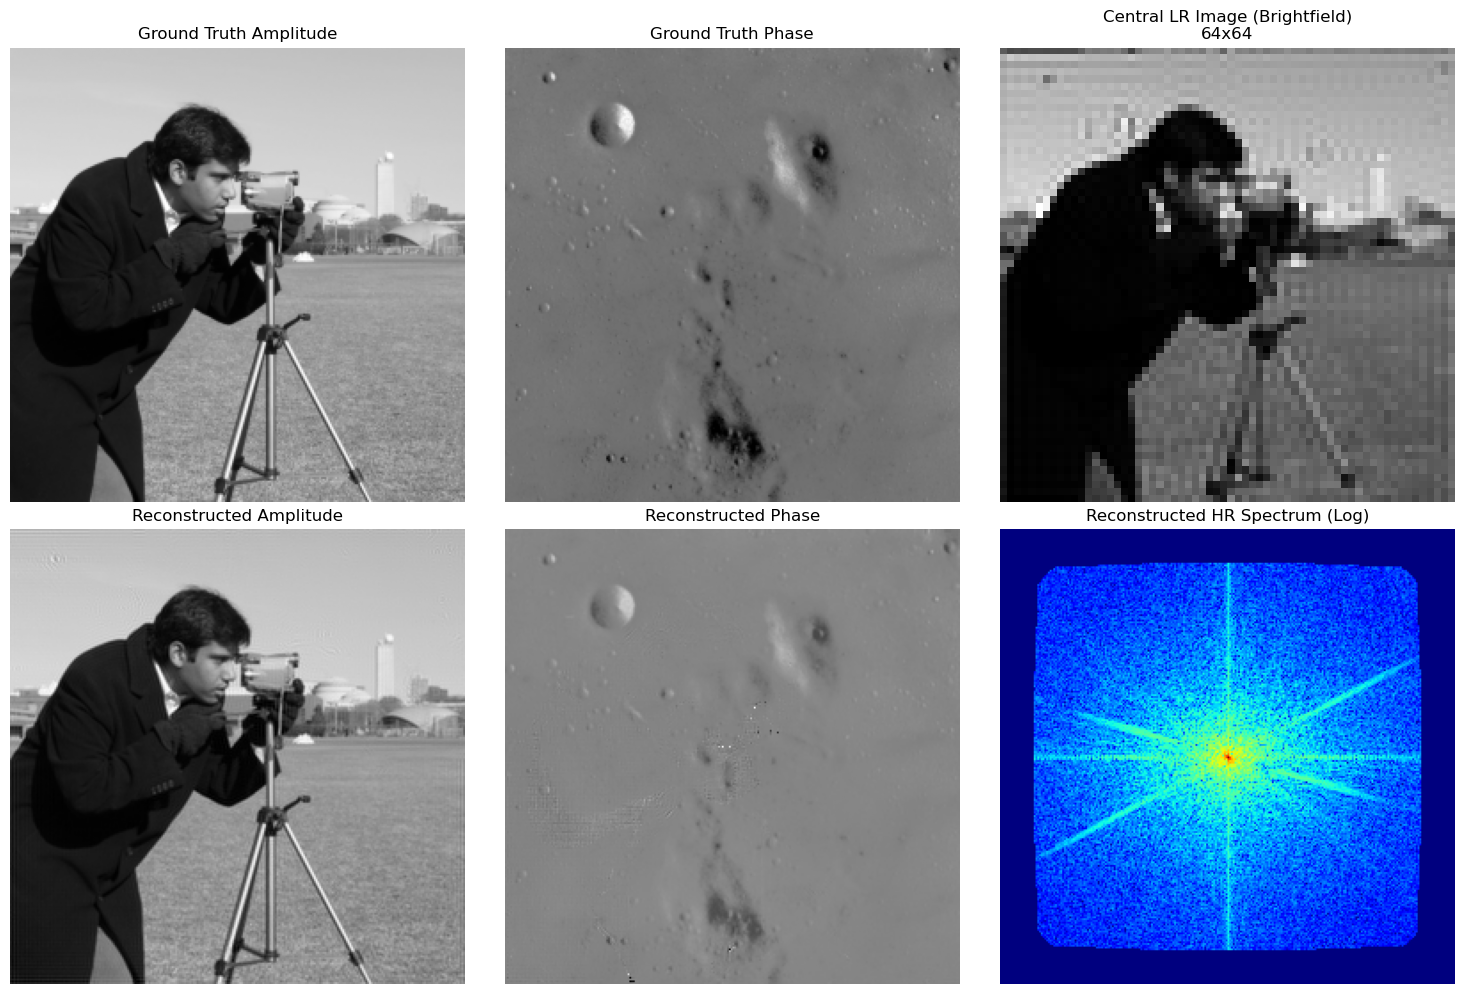

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, transform
from skimage.color import rgb2gray

def simulate_fpm():
    """
    Simulates a Fourier Ptychography Microscopy (FPM) setup and reconstruction.
    """
    # ==========================================
    # 1. System Parameters & Setup
    # ==========================================
    wavelength = 0.532e-3  # Wavelength in mm (e.g., 532 nm Green LED)
    k0 = 2 * np.pi / wavelength
    
    NA_obj = 0.1           # Objective Numerical Aperture
    mag = 2.0              # Magnification
    
    # LED Array Parameters
    led_grid_size = 7      # 7x7 LED array
    led_spacing = 4.0      # 4mm spacing between LEDs
    z_led = 60.0           # Distance from LED array to sample in mm (Assumed)
    
    # Camera / Resolution Parameters
    cam_pixel_size = 6.5e-3 # Camera pixel size in mm (e.g., 6.5 um)
    # Effective pixel size at the object plane
    dx_lr = cam_pixel_size / mag 
    
    # We define the Low-Res (LR) image size and High-Res (HR) image size
    # The upsampling factor determines the final HR pixel size
    upsample_factor = 4
    N_lr = 64              # LR image will be 64x64 pixels
    N_hr = N_lr * upsample_factor # HR image will be 256x256 pixels
    dx_hr = dx_lr / upsample_factor
    
    # ==========================================
    # 2. Create the "Ground Truth" Complex Object
    # ==========================================
    print("Preparing Ground Truth Object...")
    # Load amplitude (Cameraman) and phase (Moon)
    amp = data.camera()
    phase = data.moon()
    
    # Resize to our HR grid size
    amp = transform.resize(amp, (N_hr, N_hr), anti_aliasing=True)
    phase = transform.resize(phase, (N_hr, N_hr), anti_aliasing=True)
    
    # Normalize amplitude to [0, 1] and phase to [0, pi]
    amp = amp / np.max(amp)
    phase = (phase / np.max(phase)) * np.pi
    
    # Construct the complex high-resolution object
    obj_hr_gt = amp * np.exp(1j * phase)
    
    # Pre-compute the Fourier transform of the ground truth object
    O_hr_gt = np.fft.fftshift(np.fft.fft2(np.fft.ifftshift(obj_hr_gt)))
    
    # ==========================================
    # 3. Define Spatial and Frequency Coordinates
    # ==========================================
    # Frequency coordinates for the HR space
    fx_hr = np.fft.fftshift(np.fft.fftfreq(N_hr, d=dx_hr))
    fy_hr = np.fft.fftshift(np.fft.fftfreq(N_hr, d=dx_hr))
    FX_hr, FY_hr = np.meshgrid(fx_hr, fy_hr)
    
    # Frequency coordinates for the LR space (Pupil space)
    fx_lr = np.fft.fftshift(np.fft.fftfreq(N_lr, d=dx_lr))
    fy_lr = np.fft.fftshift(np.fft.fftfreq(N_lr, d=dx_lr))
    FX_lr, FY_lr = np.meshgrid(fx_lr, fy_lr)
    
    # Generate the Pupil Function (Coherent Transfer Function)
    # It acts as a low-pass filter with radius NA / wavelength
    cutoff_freq = NA_obj / wavelength
    pupil_radius = np.sqrt(FX_lr**2 + FY_lr**2)
    pupil = (pupil_radius <= cutoff_freq).astype(float)
    
    # ==========================================
    # 4. Forward Model: Generate LR Images
    # ==========================================
    print("Simulating LED Illuminations and capturing LR images...")
    
    # Calculate LED positions (centered at 0,0)
    led_idx = np.arange(-led_grid_size//2 + 1, led_grid_size//2 + 1)
    x_led, y_led = np.meshgrid(led_idx * led_spacing, led_idx * led_spacing)
    
    # Calculate spatial frequencies corresponding to each LED illumination angle
    # sin(theta) = x / sqrt(x^2 + z^2)
    kx_led = (x_led / np.sqrt(x_led**2 + y_led**2 + z_led**2)) / wavelength
    ky_led = (y_led / np.sqrt(x_led**2 + y_led**2 + z_led**2)) / wavelength
    
    # Array to store the simulated captured low-resolution intensities
    I_measured = np.zeros((led_grid_size, led_grid_size, N_lr, N_lr))
    
    for i in range(led_grid_size):
        for j in range(led_grid_size):
            # Shift of the spectrum in the HR Fourier plane
            shift_x = int(np.round(kx_led[i, j] * N_hr * dx_hr))
            shift_y = int(np.round(ky_led[i, j] * N_hr * dx_hr))
            
            # Define the bounding box for the pupil in the HR spectrum
            # Center of the HR spectrum is N_hr//2
            center_y = N_hr//2 + shift_y
            center_x = N_hr//2 + shift_x
            
            y_start = center_y - N_lr//2
            y_end = center_y + N_lr//2
            x_start = center_x - N_lr//2
            x_end = center_x + N_lr//2
            
            # Extract the shifted spectrum (this mimics the physical downsampling)
            # We add boundary checks in case high-angle LEDs push the pupil outside the HR grid
            if (y_start >= 0 and y_end <= N_hr and x_start >= 0 and x_end <= N_hr):
                O_shifted_crop = O_hr_gt[y_start:y_end, x_start:x_end]
            else:
                # If it falls outside, we pad with zeros (negligible for this simulation size)
                O_shifted_crop = np.zeros((N_lr, N_lr), dtype=np.complex128)
            
            # Multiply by pupil function
            E_lr_fourier = O_shifted_crop * pupil
            
            # IFFT to get the complex field at the image plane
            E_lr_spatial = np.fft.fftshift(np.fft.ifft2(np.fft.ifftshift(E_lr_fourier)))
            
            # Camera captures intensity
            I_measured[i, j, :, :] = np.abs(E_lr_spatial)**2

    # ==========================================
    # 5. Inverse Model: FPM Reconstruction
    # ==========================================
    print("Starting FPM Reconstruction...")
    
    # Initialize the HR spectrum guess with the central (brightfield) LR image
    O_recon = np.zeros((N_hr, N_hr), dtype=np.complex128)
    center_idx = led_grid_size // 2
    
    # Use the central LED image, upsampled, as our initial guess
    initial_amp = np.sqrt(I_measured[center_idx, center_idx])
    E_init_fourier = np.fft.fftshift(np.fft.fft2(np.fft.ifftshift(initial_amp)))
    O_recon[N_hr//2 - N_lr//2 : N_hr//2 + N_lr//2, 
            N_hr//2 - N_lr//2 : N_hr//2 + N_lr//2] = E_init_fourier
    
    iterations = 30
    alpha = 1.0 # Step size / relaxation parameter
    
    for it in range(iterations):
        # Optional: Print progress
        if (it+1) % 5 == 0:
            print(f"Iteration {it+1}/{iterations}")
            
        # Iterate through all LEDs
        for i in range(led_grid_size):
            for j in range(led_grid_size):
                
                # 1. Identify the region in the HR spectrum
                shift_x = int(np.round(kx_led[i, j] * N_hr * dx_hr))
                shift_y = int(np.round(ky_led[i, j] * N_hr * dx_hr))
                
                center_y = N_hr//2 + shift_y
                center_x = N_hr//2 + shift_x
                
                y_start = center_y - N_lr//2
                y_end = center_y + N_lr//2
                x_start = center_x - N_lr//2
                x_end = center_x + N_lr//2
                
                if (y_start < 0 or y_end > N_hr or x_start < 0 or x_end > N_hr):
                    continue # Skip if outside our simulated HR bandwidth bounds
                
                # 2. Extract current guess for this sub-spectrum
                O_sub = O_recon[y_start:y_end, x_start:x_end]
                
                # 3. Apply pupil function to get current LR Fourier guess
                E_est_fourier = O_sub * pupil
                
                # 4. IFFT to spatial domain
                E_est_spatial = np.fft.fftshift(np.fft.ifft2(np.fft.ifftshift(E_est_fourier)))
                
                # 5. Replace amplitude with measured amplitude, keep the phase
                amp_measured = np.sqrt(I_measured[i, j])
                E_updated_spatial = amp_measured * np.exp(1j * np.angle(E_est_spatial))
                
                # 6. FFT back to Fourier domain
                E_updated_fourier = np.fft.fftshift(np.fft.fft2(np.fft.ifftshift(E_updated_spatial)))
                
                # 7. Update the HR spectrum guess (using a standard gradient descent update)
                # We only update where the pupil is non-zero
                pupil_intensity = np.abs(pupil)**2
                max_pupil = np.max(pupil_intensity)
                
                update = (pupil * np.conj(pupil)) / max_pupil * (E_updated_fourier - E_est_fourier)
                O_recon[y_start:y_end, x_start:x_end] = O_recon[y_start:y_end, x_start:x_end] + alpha * update

    # Transform reconstructed HR spectrum back to spatial domain
    obj_recon_spatial = np.fft.fftshift(np.fft.ifft2(np.fft.ifftshift(O_recon)))
    amp_recon = np.abs(obj_recon_spatial)
    phase_recon = np.angle(obj_recon_spatial)

    # ==========================================
    # 6. Visualization
    # ==========================================
    print("Plotting Results...")
    plt.figure(figsize=(15, 10))
    
    plt.subplot(2, 3, 1)
    plt.title("Ground Truth Amplitude")
    plt.imshow(amp, cmap='gray')
    plt.axis('off')
    
    plt.subplot(2, 3, 2)
    plt.title("Ground Truth Phase")
    plt.imshow(phase, cmap='gray')
    plt.axis('off')
    
    plt.subplot(2, 3, 3)
    plt.title(f"Central LR Image (Brightfield)\n{N_lr}x{N_lr}")
    plt.imshow(I_measured[center_idx, center_idx], cmap='gray')
    plt.axis('off')
    
    plt.subplot(2, 3, 4)
    plt.title("Reconstructed Amplitude")
    plt.imshow(amp_recon, cmap='gray')
    plt.axis('off')
    
    plt.subplot(2, 3, 5)
    plt.title("Reconstructed Phase")
    plt.imshow(phase_recon, cmap='gray')
    plt.axis('off')
    
    plt.subplot(2, 3, 6)
    plt.title("Reconstructed HR Spectrum (Log)")
    plt.imshow(np.log1p(np.abs(O_recon)), cmap='jet')
    plt.axis('off')
    
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    simulate_fpm()

In [ ]:
import cv2
import os
import matplotlib.pyplot as plt

image_folder = 'HR update'
os.makedirs(image_folder, exist_ok=True)

images = [img for img in os.listdir(image_folder) if img.endswith(".png")]
images.sort() # Ensure they are in the correct order

# Read the first image to get the width and height for the video
frame = cv2.imread(os.path.join(image_folder, images[0]))
height, width, layers = frame.shape

# Setup the video writer (mp4 format)
fourcc = cv2.VideoWriter_fourcc(*'mp4v') 
video_name = 'my_results_video.mp4'
fps = 10 # Adjust frames per second to change video speed
video = cv2.VideoWriter(video_name, fourcc, fps, (width, height))

# Write each image to the video file
for image in images:
    video.write(cv2.imread(os.path.join(image_folder, image)))

# Clean up

cv2.destroyAllWindows()
video.release()

print(f"Video saved as {video_name}")